In [1]:
import pandas as pd
import pickle
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
modality = 'PL'
data_path = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/pretrain/QBioLiP/sequence_30_split/{modality}_test.pkl"
interactscore_path = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/interact_score/{modality}_test_interact_score.json"
plip_results = f"/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/case_studies/interact_score/{modality}_plip_results.csv"
esm_interact_scores = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/interact_score/{modality}_ESM2_scores.json"

In [3]:
with open(data_path, "rb") as f:
    dataset = pickle.load(f)
dataset = {item["id"]: item for item in dataset}

plip_df = pd.read_csv(plip_results)

interact_scores = []
with open(interactscore_path, "r") as f:
    for line in f:
        interact_scores.append(json.loads(line))
interact_scores = {item["id"]: item for item in interact_scores}

with open(esm_interact_scores, 'r') as f:
    esm_interact_scores = json.load(f)
for key, esm_interact_score in esm_interact_scores.items():
    esm_interact_scores[key] = {int(k): float(v) for k, v in esm_interact_score.items()}

In [4]:
def map_to_block_idx(row):
    item = dataset[row["item_id"]]
    block_to_pdb_idx = item['block_to_pdb_indexes']
    pdb_to_block_idx = {pdb_idx: block_idx for block_idx, pdb_idx in block_to_pdb_idx.items()}
    pdb_idx = f'{row["reschain"]}_{row["resnr"]}'
    return pdb_to_block_idx.get(pdb_idx, -1)

def get_interact_score(row):
    item = interact_scores[row["item_id"]]
    block_idx = row["block_idx"]
    if block_idx == -1:
        return None
    return item['cos_distances'][item['block_idx'].index(block_idx)]    

def get_interact_rank(row):
    item = interact_scores[row["item_id"]]
    block_idx = row["block_idx"]
    if block_idx == -1:
        return None
    return np.argsort(item['cos_distances'])[item['block_idx'].index(block_idx)]/len(item['cos_distances'])

plip_df['block_idx'] = plip_df.apply(map_to_block_idx, axis=1)
plip_df['interact_score'] = plip_df.apply(get_interact_score, axis=1)
plip_df['interact_rank'] = plip_df.apply(get_interact_rank, axis=1)
plip_df = plip_df.dropna().copy()

print("Number of items:", len(plip_df["item_id"].unique()))

Number of items: 6108


In [5]:
plip_df['item_block'] = plip_df.apply(lambda row: (row['item_id'], row['block_idx']), axis=1)
plip_item_block_to_bond_type = {item_block: bond_type for item_block, bond_type in zip(plip_df['item_block'], plip_df['bondtype'])}

In [10]:
retreival_results = []
topk = 10

bond_types = plip_df['bondtype'].unique().tolist()

for item_id, item in dataset.items():
    pocket_blocks = item['block_to_pdb_indexes']
    if len(pocket_blocks) < topk:
        continue
    if not item_id in plip_df['item_id'].values:
        continue # no plip results for this item

    bond_counter = plip_df[plip_df['item_id'] == item_id]['bondtype'].value_counts().to_dict()
    scores = np.array(interact_scores[item_id]['cos_distances'])
    score_block_idx = np.array(interact_scores[item_id]['block_idx'])
    mask_scores = np.array([block_idx in pocket_blocks for block_idx in score_block_idx])
    scores = scores[mask_scores]
    score_block_idx = score_block_idx[mask_scores]

    topk_idx = np.argsort(scores)[:topk] # lowest scores
    topk_block_idx = score_block_idx[topk_idx]

    rand_block_idx = np.random.choice(score_block_idx, topk, replace=False)

    topk_bond_types = [plip_item_block_to_bond_type.get((item_id, block_idx), None) for block_idx in topk_block_idx]
    topk_bond_type_counter = {f"topk_{bond_type}": topk_bond_types.count(bond_type) for bond_type in bond_types}
    rand_bond_types = [plip_item_block_to_bond_type.get((item_id, block_idx), None) for block_idx in rand_block_idx]
    rand_bond_type_counter = {f"rand_{bond_type}": rand_bond_types.count(bond_type) for bond_type in bond_types}

    topk_bond_type_proportion = {
        f"topk_proportion_{bond_type}": topk_bond_type_counter[f"topk_{bond_type}"]/min(bond_counter[bond_type], topk)
        for bond_type in bond_types 
        if bond_type in bond_counter and bond_counter[bond_type] != 0
    }
    rand_bond_type_proportion = {
        f"rand_proportion_{bond_type}": rand_bond_type_counter[f"rand_{bond_type}"]/min(bond_counter[bond_type], topk)
        for bond_type in bond_types 
        if bond_type in bond_counter and bond_counter[bond_type] != 0
    }
    
    retreival_results.append({
        "item_id": item_id,
        **topk_bond_type_counter,
        **rand_bond_type_counter,
        "topk_total": sum(topk_bond_type_counter.values()),
        "rand_total": sum(rand_bond_type_counter.values()),
        **topk_bond_type_proportion,
        **rand_bond_type_proportion,
        "topk_recall": sum(topk_bond_type_counter.values())/sum(bond_counter.values()),
        "rand_recall": sum(rand_bond_type_counter.values())/sum(bond_counter.values()),
        **bond_counter
    })
retreival_results = pd.DataFrame(retreival_results)
print(len(retreival_results))

5691


In [11]:
def get_esm_score(row):
    if row["item_id"] not in esm_interact_scores:
        return None

    item = esm_interact_scores[row["item_id"]]
    block_idx = row["block_idx"]
    if block_idx == -1:
        return None
    return item[block_idx]

def get_esm_rank(row):
    if row["item_id"] not in esm_interact_scores:
        return None
    
    item = esm_interact_scores[row["item_id"]]
    sorted_item = sorted(((v,k) for k,v in item.items()), reverse=True)
    for i, (score, block_idx) in enumerate(sorted_item):
        if block_idx == row["block_idx"]:
            return i/len(item)

plip_df['esm_score'] = plip_df.apply(get_esm_score, axis=1)
plip_df['esm_rank'] = plip_df.apply(get_esm_rank, axis=1)

esm_retreival_results = []
for item_id in retreival_results['item_id']:
    if item_id not in esm_interact_scores:
        continue
    item = dataset[item_id]
    pocket_blocks = item['block_to_pdb_indexes']
    if len(pocket_blocks) < topk:
        continue
    if not item_id in plip_df['item_id'].values:
        continue # no plip results for this item

    bond_counter = plip_df[plip_df['item_id'] == item_id]['bondtype'].value_counts().to_dict()

    scores = np.array([esm_interact_scores[item_id][block_idx] for block_idx in pocket_blocks])
    score_block_idx = np.array([block_idx for block_idx in pocket_blocks])
    esm_idx = np.argsort(scores)[-topk:] # highest scores
    esm_block_idx = score_block_idx[esm_idx]

    esm_bond_types = [plip_item_block_to_bond_type.get((item_id, block_idx), None) for block_idx in esm_block_idx]
    esm_bond_type_counter = {f"esm_{bond_type}": esm_bond_types.count(bond_type) for bond_type in bond_types}

    esm_bond_type_proportion = {
        f"esm_proportion_{bond_type}": esm_bond_type_counter[f"esm_{bond_type}"]/min(bond_counter[bond_type], topk)
        for bond_type in bond_types 
        if bond_type in bond_counter and bond_counter[bond_type] != 0
    }

    esm_retreival_results.append({
        "item_id": item_id,
        **esm_bond_type_counter,
        "esm_total": sum(esm_bond_type_counter.values()),
        **esm_bond_type_proportion,
        "esm_recall": sum(esm_bond_type_counter.values())/sum(bond_counter.values()),
    })
esm_retreival_results = pd.DataFrame(esm_retreival_results)

In [12]:
retreival_results = retreival_results.merge(esm_retreival_results, on="item_id", how="inner")
print(len(retreival_results))

5691


In [17]:
retreival_results[['topk_total', 'rand_total', 'esm_total']].describe()

,topk_total,rand_total,esm_total
count,5691.000000,5691.000000,5691.000000
mean,2.714110,1.975927,2.370234
std,1.459582,1.256246,1.460007
min,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000
50%,3.000000,2.000000,2.000000
75%,4.000000,3.000000,3.000000
max,8.000000,7.000000,8.000000


In [16]:
retreival_results[['topk_recall', 'rand_recall', 'esm_recall']].describe()

,topk_recall,rand_recall,esm_recall
count,5691.000000,5691.000000,5691.000000
mean,0.403772,0.312820,0.364090
std,0.259102,0.261533,0.277022
min,0.000000,0.000000,0.000000
25%,0.222222,0.125000,0.166667
50%,0.333333,0.250000,0.300000
75%,0.500000,0.428571,0.500000
max,1.000000,1.000000,1.000000


In [18]:
retreival_results_to_save = retreival_results[[col for col in retreival_results.columns if not "proportion" in col]].copy()
for bond_type in ['pi-Stacking', 'Hydrophobic Interactions', 'Metal Complexes', 'Halogen Bonds', 'Hydrogen Bonds']:
    retreival_results_to_save[bond_type] = retreival_results_to_save[bond_type].fillna(0).astype(int)
retreival_results_to_save.to_csv('ATOMICAScore_protein_small_molecule_results.csv', index=False)

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


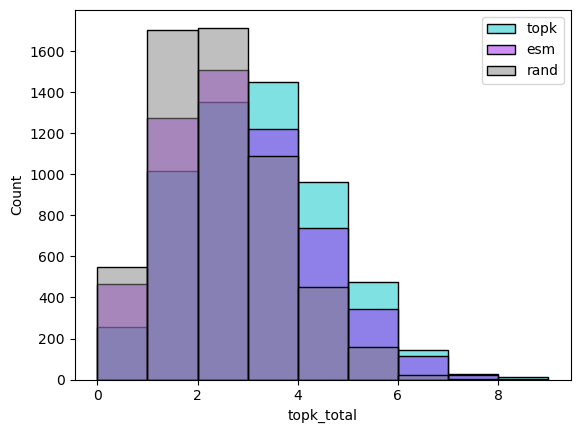

In [12]:
color_topk = '#00C4C7'
color_esm = '#A020F0'
color_rand = '#808080'
sns.histplot(retreival_results[f"topk_total"], bins=range(0, topk), color=color_topk, alpha=0.5, label='topk')
sns.histplot(retreival_results[f"esm_total"], bins=range(0, topk), color=color_esm, alpha=0.5, label='esm')
sns.histplot(retreival_results[f"rand_total"], bins=range(0, topk), color=color_rand, alpha=0.5, label='rand')
plt.legend()
plt.show()

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na 

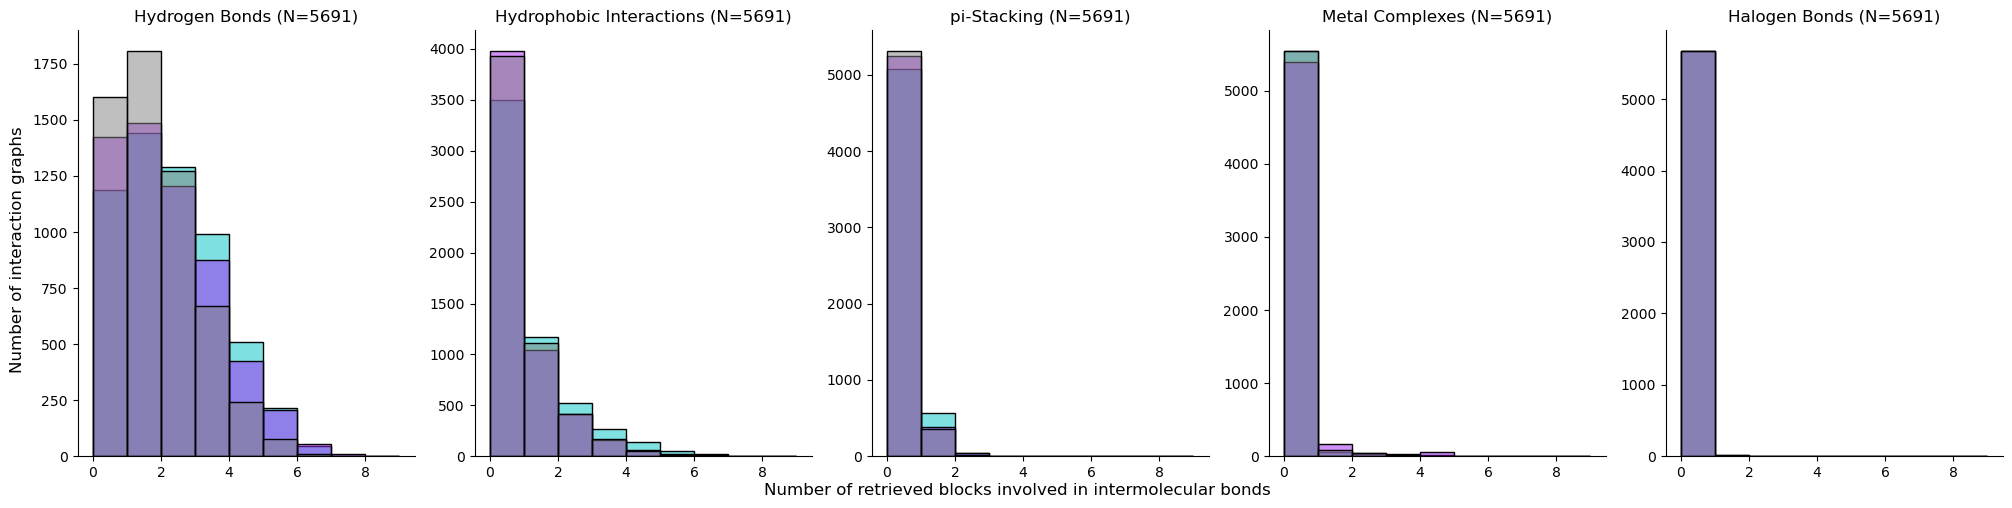

In [13]:
fig, ax = plt.subplots(1, len(bond_types), figsize=(20, 5))
color_topk = '#00C4C7'
color_esm = '#A020F0'
color_rand = '#808080'
for i, bond_type in enumerate(bond_types):
    retreival_results_bond_type = retreival_results.dropna(subset=[bond_type])
    sns.histplot(retreival_results_bond_type[f"topk_{bond_type}"], bins=range(0, topk), color=color_topk, alpha=0.5, label='topk', ax=ax[i])
    sns.histplot(retreival_results_bond_type[f"esm_{bond_type}"], bins=range(0, topk), color=color_esm, alpha=0.5, label='esm', ax=ax[i])
    sns.histplot(retreival_results_bond_type[f"rand_{bond_type}"], bins=range(0, topk), color=color_rand, alpha=0.5, label='rand', ax=ax[i])

    ax[i].set_title(f"{bond_type} (N={len(retreival_results_bond_type['item_id'].unique())})")
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
fig.text(0.5, 0.0, 'Number of retrieved blocks involved in intermolecular bonds', ha='center', fontsize=12)
fig.text(0.0, 0.25, 'Number of interaction graphs', ha='center', rotation='vertical', fontsize=12)
plt.tight_layout()
plt.savefig("figs/topk_vs_rand_interact_score_interaction_type.svg", format='svg', transparent=True)
plt.show()

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na 

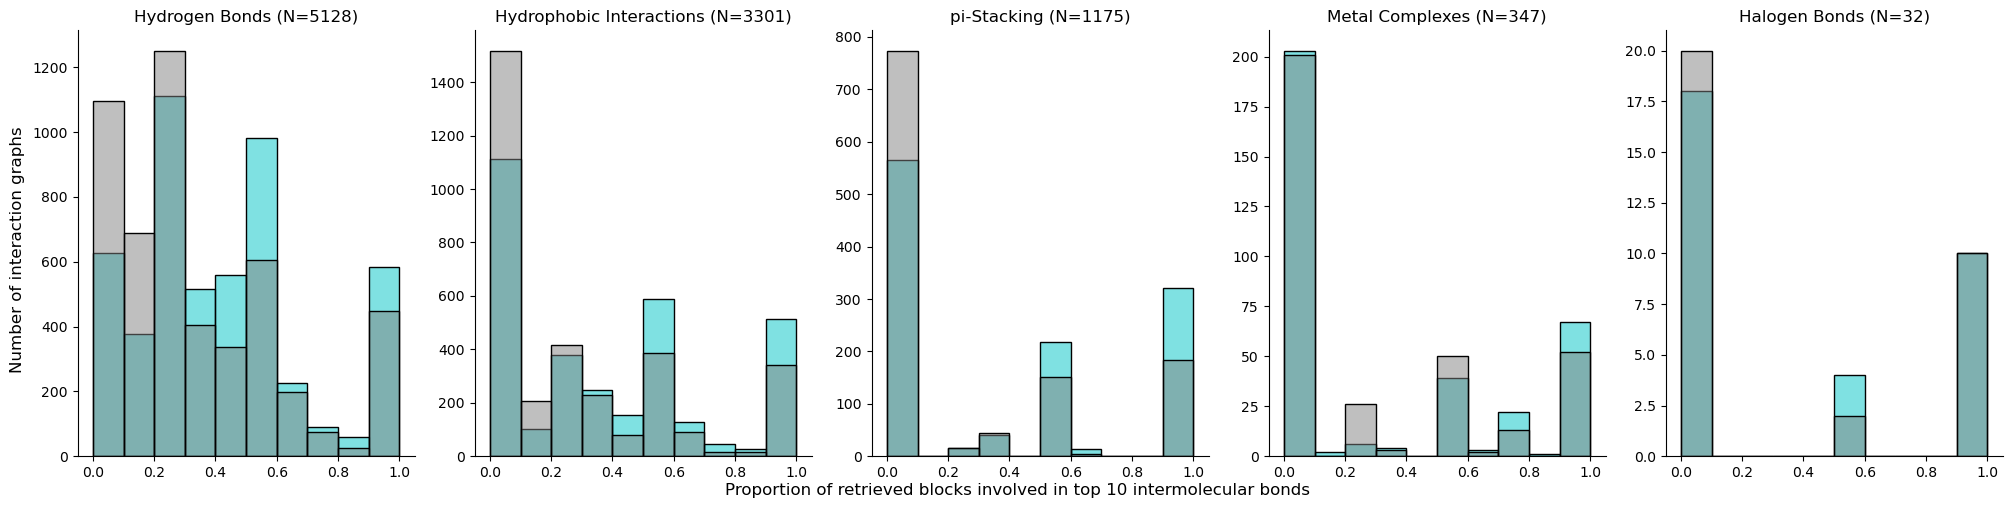

In [23]:
fig, ax = plt.subplots(1, len(bond_types), figsize=(20, 5))
color_topk = '#00C4C7'
color_rand = '#808080'
bins = np.linspace(0, 1, 11)
for i, bond_type in enumerate(bond_types):
    retreival_results_bond_type = retreival_results.dropna(subset=[bond_type])
    sns.histplot(retreival_results_bond_type[f"topk_proportion_{bond_type}"], bins=bins, color=color_topk, alpha=0.5, label='topk', ax=ax[i])
    sns.histplot(retreival_results_bond_type[f"rand_proportion_{bond_type}"], bins=bins, color=color_rand, alpha=0.5, label='rand', ax=ax[i])
    ax[i].set_title(f"{bond_type} (N={len(retreival_results_bond_type['item_id'].unique())})")
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
fig.text(0.5, 0.0, f'Proportion of retrieved blocks involved in top {topk} intermolecular bonds', ha='center', fontsize=12)
fig.text(0.0, 0.25, 'Number of interaction graphs', ha='center', rotation='vertical', fontsize=12)
plt.tight_layout()
# plt.savefig("figs/topk_vs_rand_interact_score_interaction_type.svg", format='svg', transparent=True)
plt.show()

In [ ]:
from scipy.stats import ks_2samp
ks_results = []
ks_stat = ks_2samp(retreival_results[f"topk_total"], retreival_results[f"rand_total"])
ks_results.append(("Overall", ks_stat.statistic, ks_stat.pvalue))

for bond_type in bond_types:
    retreival_results_bond_type = retreival_results.dropna(subset=[bond_type])
    ks_stat = ks_2samp(retreival_results_bond_type[f"topk_{bond_type}"], retreival_results_bond_type[f"rand_{bond_type}"])
    ks_results.append((bond_type, ks_stat.statistic, ks_stat.pvalue))

ks_results = pd.DataFrame(ks_results, columns=["bond_type", "ks_statistic", "pvalue"])
ks_results

,bond_type,ks_statistic,pvalue
0,Overall,0.228431,1.580645e-130
1,Hydrogen Bonds,0.154251,1.272530e-53
2,Hydrophobic Interactions,0.118752,1.095461e-20
3,pi-Stacking,0.177872,1.193282e-16
4,Metal Complexes,0.080692,2.087699e-01
5,Halogen Bonds,0.031250,1.000000e+00


In [ ]:
from scipy.stats import ks_2samp
ks_results = []
ks_stat = ks_2samp(retreival_results[f"topk_total"], retreival_results[f"esm_total"])
ks_results.append(("Overall", ks_stat.statistic, ks_stat.pvalue))

for bond_type in bond_types:
    retreival_results_bond_type = retreival_results.dropna(subset=[bond_type])
    ks_stat = ks_2samp(retreival_results_bond_type[f"topk_{bond_type}"], retreival_results_bond_type[f"esm_{bond_type}"])
    ks_results.append((bond_type, ks_stat.statistic, ks_stat.pvalue))

ks_results = pd.DataFrame(ks_results, columns=["bond_type", "ks_statistic", "pvalue"])
ks_results

,bond_type,ks_statistic,pvalue
0,Overall,0.110525,1.120905e-30
1,Hydrogen Bonds,0.054797,4.083768e-07
2,Hydrophobic Interactions,0.146016,4.271328e-31
3,pi-Stacking,0.144681,3.856953e-11
4,Metal Complexes,0.440922,1.042416e-30
5,Halogen Bonds,0.062500,1.000000e+00


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


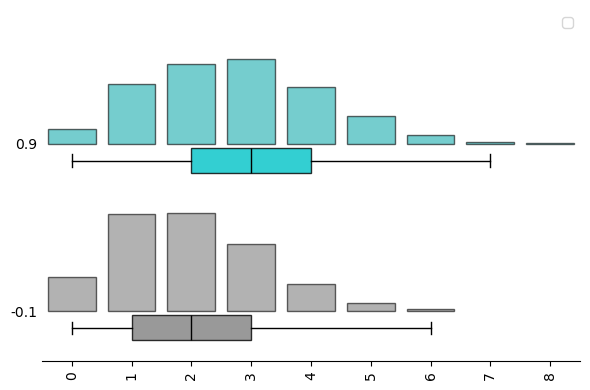

In [33]:
# Figure and axis setup
fig, ax = plt.subplots(figsize=(6,4))
color_topk = '#00C4C7'
color_rand = '#808080'

# Data for box plots
data_x = [retreival_results['rand_total'], retreival_results['topk_total']]

# Box plot
bp = ax.boxplot(data_x, patch_artist=True, vert=False, positions=[-0.1,0.9], showfliers=False)
boxplots_colors = [color_rand, color_topk]

# Modify the color of the boxplots
for i, (box, color) in enumerate(zip(bp['boxes'], boxplots_colors)):
    # Set the color for box
    box.set_facecolor(color)
    box.set_alpha(0.8)
    box.set_edgecolor('black')
    for whisker in bp['whiskers'][i*2:i*2+2]:
        whisker.set_color('black')
    for cap in bp['caps'][i*2:i*2+2]:
        cap.set_color('black')
    bp['medians'][i].set_color('black')

# Data for bar plots (categorical value counts)
counts_topk = np.bincount(retreival_results['topk_total'], minlength=11)/20
counts_rand = np.bincount(retreival_results['rand_total'], minlength=11)/20

topk_count = retreival_results['topk_total'].value_counts().sort_index().reset_index()
topk_count['count'] /= sum(topk_count['count'])/2
sns.barplot(data=topk_count, x='topk_total', y='count', color=color_topk, alpha=0.6, ax=ax, edgecolor='black', bottom=1)
rand_count = retreival_results['rand_total'].value_counts().sort_index().reset_index()
rand_count['count'] /= sum(rand_count['count'])/2
sns.barplot(data=rand_count, x='rand_total', y='count', color=color_rand, alpha=0.6, ax=ax, edgecolor='black', bottom=0)

# Set axis labels and title
# ax.set_xlabel('Number of retrieved blocks involved in intermolecular bonds')
ax.set_xlabel("")
ax.set_xticks(range(11))
ax.set_xticklabels(range(11), rotation=90)
ax.set_yticks([0, 1])
ax.set_ylim(-0.3, 1.8)
# ax.set_title('Box plots and bar plots for Topk and Rand')

# Show the legend
ax.legend(loc='upper right')

# Despine the plot and remove y-axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  # This is despining the left spine
ax.yaxis.set_tick_params(length=0)
ax.set_ylabel('')
ax.set_xlim(-0.5,8.5)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("figs/topk_vs_rand_interact_score.svg", format='svg', transparent=True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


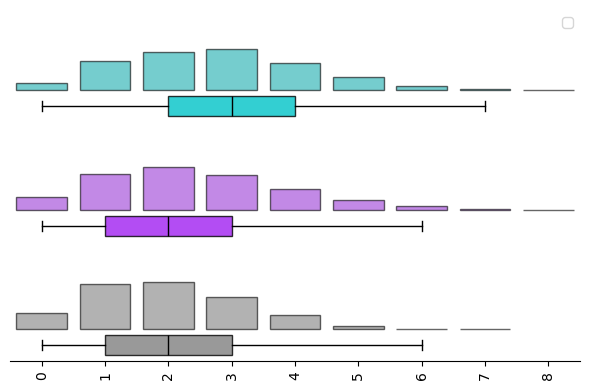

In [48]:
# Figure and axis setup
fig, ax = plt.subplots(figsize=(6,4))
color_topk = '#00C4C7'
color_rand = '#808080'
color_esm = '#A020F0'

# Data for box plots
data_x = [retreival_results['rand_total'], retreival_results['esm_total'], retreival_results['topk_total']]

# Box plot
bp = ax.boxplot(data_x, patch_artist=True, vert=False, positions=[0-0.4,3-0.4,6-0.4], showfliers=False)
boxplots_colors = [color_rand, color_esm, color_topk]

# Modify the color of the boxplots
for i, (box, color) in enumerate(zip(bp['boxes'], boxplots_colors)):
    # Set the color for box
    box.set_facecolor(color)
    box.set_alpha(0.8)
    box.set_edgecolor('black')
    for whisker in bp['whiskers'][i*2:i*2+2]:
        whisker.set_color('black')
    for cap in bp['caps'][i*2:i*2+2]:
        cap.set_color('black')
    bp['medians'][i].set_color('black')

# Data for bar plots (categorical value counts)
counts_topk = np.bincount(retreival_results['topk_total'], minlength=11)
counts_esm = np.bincount(retreival_results['esm_total'], minlength=11)
counts_rand = np.bincount(retreival_results['rand_total'], minlength=11)

topk_count = retreival_results['topk_total'].value_counts().sort_index().reset_index()
topk_count['count'] /= sum(topk_count['count'])/4
sns.barplot(data=topk_count, x='topk_total', y='count', color=color_topk, alpha=0.6, ax=ax, edgecolor='black', bottom=6)
esm_count = retreival_results['esm_total'].value_counts().sort_index().reset_index()
esm_count['count'] /= sum(esm_count['count'])/4
sns.barplot(data=esm_count, x='esm_total', y='count', color=color_esm, alpha=0.6, ax=ax, edgecolor='black', bottom=3)
rand_count = retreival_results['rand_total'].value_counts().sort_index().reset_index()
rand_count['count'] /= sum(rand_count['count'])/4
sns.barplot(data=rand_count, x='rand_total', y='count', color=color_rand, alpha=0.6, ax=ax, edgecolor='black', bottom=0)

# Set axis labels and title
# ax.set_xlabel('Number of retrieved blocks involved in intermolecular bonds')
ax.set_xlabel("")
ax.set_xticks(range(11))
ax.set_xticklabels(range(11), rotation=90)
ax.set_yticks([])
ax.set_ylim(-0.8, 8)
# ax.set_title('Box plots and bar plots for Topk and Rand')

# Show the legend
ax.legend(loc='upper right')

# Despine the plot and remove y-axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  # This is despining the left spine
ax.yaxis.set_tick_params(length=0)
ax.set_ylabel('')
ax.set_xlim(-0.5,8.5)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("figs/topk_vs_rand_vs_esm_interact_score.svg", format='svg', transparent=True)
plt.show()

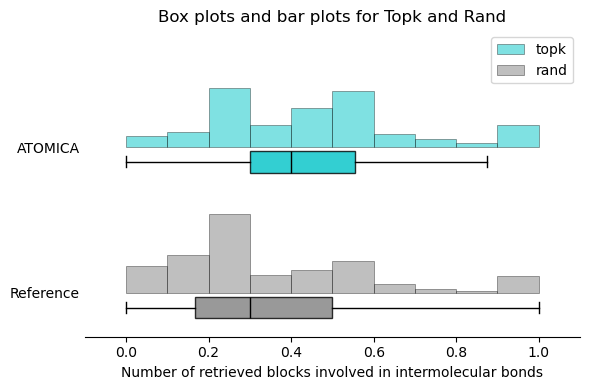

In [ ]:
# Figure and axis setup
fig, ax = plt.subplots(figsize=(6,4))
color_topk = '#00C4C7'
color_rand = '#808080'

# Data for box plots
data_x = [retreival_results['rand_proportion'], retreival_results['topk_proportion']]

# Box plot
bp = ax.boxplot(data_x, patch_artist=True, vert=False, positions=[-0.1,0.9], showfliers=False)
boxplots_colors = [color_rand, color_topk]

# Modify the color of the boxplots
for i, (box, color) in enumerate(zip(bp['boxes'], boxplots_colors)):
    # Set the color for box
    box.set_facecolor(color)
    box.set_alpha(0.8)
    box.set_edgecolor('black')
    for whisker in bp['whiskers'][i*2:i*2+2]:
        whisker.set_color('black')
    for cap in bp['caps'][i*2:i*2+2]:
        cap.set_color('black')
    bp['medians'][i].set_color('black')

# Data for bar plots (categorical value counts)
counts_topk = np.bincount(retreival_results['topk_proportion'], minlength=11)/20
counts_rand = np.bincount(retreival_results['rand_proportion'], minlength=11)/20

ax.hist(retreival_results['topk_proportion'], bins=np.linspace(0, 1, 11), color=color_topk, alpha=0.5, label='topk', bottom=1, 
        weights=np.ones_like(retreival_results['topk_proportion']) * 0.0003, linewidth=0.5, edgecolor='black')
ax.hist(retreival_results['rand_proportion'], bins=np.linspace(0, 1, 11), color=color_rand, alpha=0.5, label='rand', bottom=0,
        weights=np.ones_like(retreival_results['rand_proportion']) * 0.0003, linewidth=0.5, edgecolor='black')

# Set axis labels and title
ax.set_xlabel('Number of retrieved blocks involved in intermolecular bonds')
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Reference', 'ATOMICA'])
ax.set_ylim(-0.3, 1.8)
ax.set_title('Box plots and bar plots for Topk and Rand')

# Show the legend
ax.legend(loc='upper right')

# Despine the plot and remove y-axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  # This is despining the left spine
ax.yaxis.set_tick_params(length=0)
ax.set_ylabel('')
ax.set_xlim(-0.1,1.1)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("figs/topk_vs_rand_interact_score.svg", format='svg', transparent=True)
plt.show()

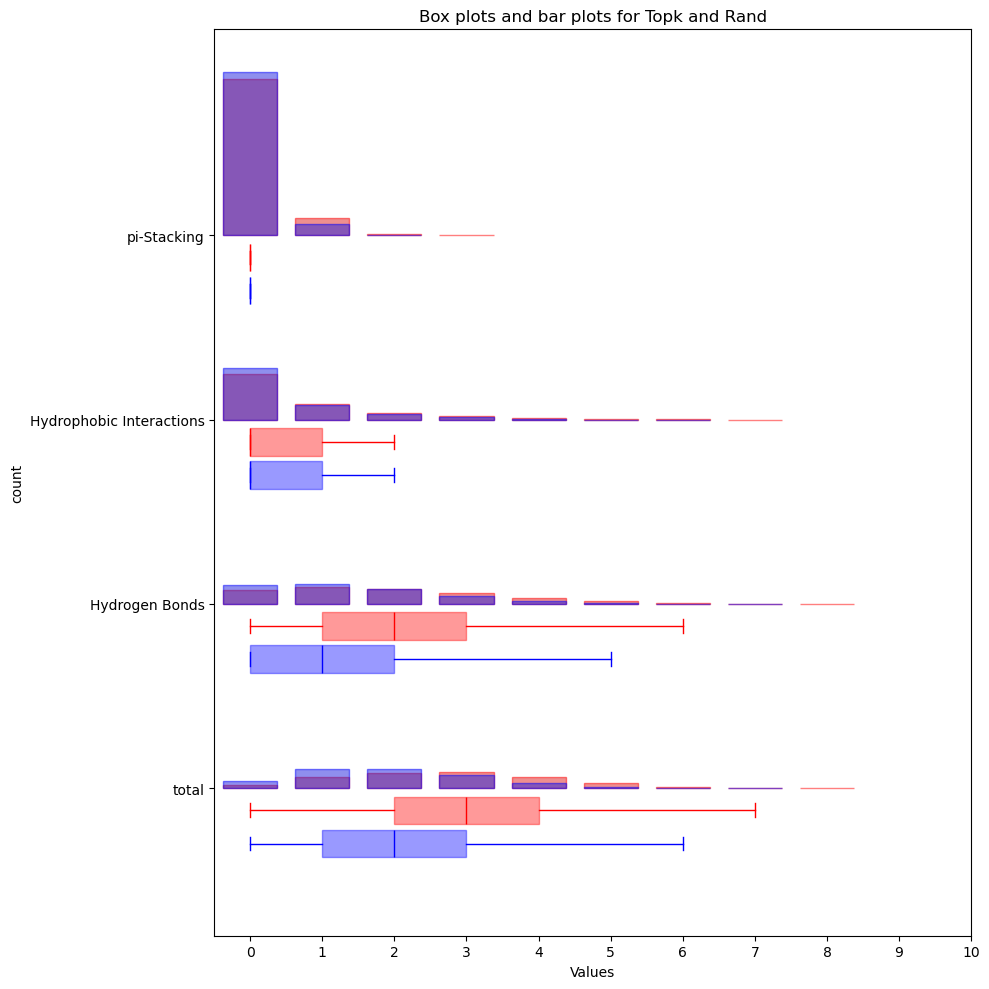

In [210]:
# Figure and axis setup
fig, ax = plt.subplots(figsize=(10, 10))

color_topk = 'red'
color_rand = 'blue'

plot_bond_types = ['total', 'Hydrogen Bonds', 'Hydrophobic Interactions', 'pi-Stacking']

for bottom, bond_type in enumerate(plot_bond_types):
    # Data for box plots
    data_x = [retreival_results[f'topk_{bond_type}'], retreival_results[f'rand_{bond_type}']]
    boxplots_colors = [color_topk, color_rand]

    # Box plot
    bp = ax.boxplot(data_x, patch_artist=True, vert=False, positions=[bottom-0.12, bottom-0.3], showfliers=False)

    # Modify the color of the boxplots
    for i, (box, color) in enumerate(zip(bp['boxes'], boxplots_colors)):
        # Set the color for box
        box.set_facecolor(color)
        box.set_edgecolor(color)
        box.set_alpha(0.4)
        for whisker in bp['whiskers'][i*2:i*2+2]:
            whisker.set_color(color)
        for cap in bp['caps'][i*2:i*2+2]:
            cap.set_color(color)
        bp['medians'][i].set_color(color)

    # Data for bar plots (categorical value counts)
    counts_topk = np.bincount(retreival_results[f'topk_{bond_type}'], minlength=11)/20
    counts_rand = np.bincount(retreival_results[f'rand_{bond_type}'], minlength=11)/20

    count_normalize_factor = max(retreival_results[f'topk_{bond_type}'].max(), retreival_results[f'rand_{bond_type}'].max())*2000
    topk_count = retreival_results[f'topk_{bond_type}'].value_counts().sort_index().reset_index()
    topk_count['count'] /= count_normalize_factor
    sns.barplot(data=topk_count, x=f'topk_{bond_type}', y='count', color=color_topk, alpha=0.5, ax=ax, bottom=bottom, edgecolor=color_topk, width=0.75)
    rand_count = retreival_results[f'rand_{bond_type}'].value_counts().sort_index().reset_index()
    rand_count['count'] /= count_normalize_factor
    sns.barplot(data=rand_count, x=f'rand_{bond_type}', y='count', color=color_rand, alpha=0.5, ax=ax, bottom=bottom, edgecolor=color_rand, width=0.75)

# Set axis labels and title
ax.set_xlabel('Values')
ax.set_xticks(range(11))
ax.set_xticklabels(range(11))
ax.set_yticks(range(len(plot_bond_types)))
ax.set_yticklabels(plot_bond_types)
ax.set_title('Box plots and bar plots for Topk and Rand')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()